Group Members 
MS KHANYILE  22354752
T MBUTHUMA   22329027
SS NGOBESE   22335678
S NOMBIKA    22312280

## Problem Statement 



Flooding is a recurring environmental hazard that can cause significant damage to communities, infrastructure, agriculture, and ecosystems. One important indicator of potential flooding is an unusually high river flow. However, identifying periods of elevated flood risk in advance can be challenging when relying solely on historical observations and manual monitoring.
This project aims to develop a machine learning-based river-flow forecasting system that uses historical river measurements, including river level, flow rate, date, and time, to predict future river flow conditions. The predicted flow will then be compared against statistically or scientifically established thresholds to classify the potential level of flood risk.
The system will focus initially on historical observations from the Mlalazi River at Eshowe and will investigate whether patterns in previous river-flow and water-level measurements can be used to forecast future high-flow events. The ultimate goal is to provide an early-warning indicator that can identify potentially high or very high river-flow conditions, supporting proactive flood-risk monitoring and decision-making.


## 2.Importing the required libraries 

In [45]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
plt.rcParams["figure.figsize"] = (11, 4)
plt.rcParams["axes.grid"] = True

RAW_PATH = "W1H004PK.CSV"

def load_raw(path):
    with open(path, "r", encoding="latin1") as f:
        lines = f.readlines()
    header_idx = next(i for i, l in enumerate(lines) if l.strip().startswith("Year,Date,Time"))
    records = []
    for l in lines[header_idx + 1:]:
        l = l.rstrip("\n")
        if not l.strip() or l.strip().startswith("Explanation") or "\x0c" in l:
            continue
        parts = l.split(",")
        if len(parts) < 5:
            continue
        records.append({
            "date_raw": parts[1].strip(),
            "level_raw": parts[3].strip(),
            "flow_raw": parts[4].strip(),
            "flag": parts[5].strip() if len(parts) > 5 else "",
        })
    df = pd.DataFrame(records)
    df["date"] = pd.to_datetime(df["date_raw"], format="%Y%m%d")
    df["level"] = pd.to_numeric(df["level_raw"], errors="coerce")
    df["flow"] = pd.to_numeric(df["flow_raw"], errors="coerce")
    return df.sort_values("date").reset_index(drop=True)[["date", "level", "flow", "flag"]]

df = load_raw(RAW_PATH)
print(f"Loaded {len(df)} records, {df['date'].min().date()} to {df['date'].max().date()}")
df.head()


Loaded 937 records, 1948-07-01 to 2026-07-01


,date,level,flow,flag
0,1948-07-01,NaN,NaN,M
1,1948-08-26,0.055,0.067,M
2,1948-09-19,0.061,0.078,
3,1948-10-09,0.061,0.078,
4,1948-11-24,0.204,0.694,


## 3.Data Understanding 



In [46]:
print("Shape:", df.shape)
print(df.dtypes)
print()
print("Duplicate exact dates:", df["date"].duplicated().sum())
print("Duplicate (year, month):", df["date"].dt.to_period("M").duplicated().sum())

Shape: (937, 4)
date     datetime64[us]
level           float64
flow            float64
flag                str
dtype: object

Duplicate exact dates: 0
Duplicate (year, month): 0


Verify true observation frequency: is this really one record per calendar month?

In [47]:
gaps = df["date"].diff().dt.days
print("Day-gap between consecutive records:")
print(gaps.describe())

ym = df["date"].dt.to_period("M")
full_range = pd.period_range(ym.min(), ym.max(), freq="M")
missing_months = set(full_range) - set(ym)
print(f"\nCalendar months in span: {len(full_range)}, with NO observation: {len(missing_months)}")
print("=> Despite day-gaps ranging widely (DWS records the day the monthly MAX occurred, not a")
print("   fixed date), this confirms exactly one observation per calendar month, no month skipped.")

Day-gap between consecutive records:
count    936.000000
mean      30.436966
std       13.355937
min        1.000000
25%       22.000000
50%       31.000000
75%       39.000000
max       61.000000
Name: date, dtype: float64

Calendar months in span: 937, with NO observation: 0
=> Despite day-gaps ranging widely (DWS records the day the monthly MAX occurred, not a
   fixed date), this confirms exactly one observation per calendar month, no month skipped.


In [48]:
print("Quality flag counts:")
print(df["flag"].value_counts())


Quality flag counts:
flag
     828
M     41
Q     35
Z     19
<      8
$      5
>      1
Name: count, dtype: int64


Investigating what each flag actually means (rather than trusting the legend blindly):

In [49]:
for flag_val in ["M", "Z", "Q", "<", ">", "$"]:
    sub = df[df["flag"] == flag_val]
    if len(sub) == 0:
        continue
    n_blank = sub["flow"].isna().sum()
    print(f"Flag '{flag_val}': n={len(sub):3d}  date range {sub['date'].min().date()} to "
          f"{sub['date'].max().date()}  | flow missing: {n_blank}/{len(sub)}")


Flag 'M': n= 41  date range 1948-07-01 to 2026-07-01  | flow missing: 14/41
Flag 'Z': n= 19  date range 1987-09-29 to 1989-09-01  | flow missing: 19/19
Flag 'Q': n= 35  date range 2023-08-16 to 2026-06-01  | flow missing: 0/35
Flag '<': n=  8  date range 2015-09-01 to 2016-07-31  | flow missing: 0/8
Flag '>': n=  1  date range 1949-04-29 to 1949-04-29  | flow missing: 0/1
Flag '$': n=  5  date range 2015-07-22 to 2016-06-30  | flow missing: 0/5


Findings:

M ("Missing Data" per the legend) — but only 14 of 41 M rows are actually blank; the other 27 carry real level and flow values. The legend name doesn't literally hold; most likely these are estimated/infilled readings rather than directly logged ones. Treated with caution below.
Z ("no info for stage/discharge determination") — 19 rows, Sep 1987–Sep 1989, always has level but never flow. Confirms flow is rating-curve-derived, not independently measured (see Stage 1).
Q (not yet audited) — 35 rows, all Aug 2023–Jun 2026, the most recent stretch of the record.
<, >, $ — small counts (2015–2016), legitimate near-zero / manually-read values, not errors.

In [50]:
print("Flow descriptive stats (cumec):")
print(df["flow"].describe(percentiles=[.5,.75,.9,.95,.99]))
print(f"\nZero-flow months: {(df['flow']==0).sum()}")
print(f"\nTop 5 highest-flow events on record:")
print(df.nlargest(5, "flow")[["date","level","flow","flag"]])

Flow descriptive stats (cumec):
count    904.000000
mean       1.570149
std       11.020802
min        0.000000
50%        0.120000
75%        0.552000
90%        2.194400
95%        4.929450
99%       22.918210
max      297.330000
Name: flow, dtype: float64

Zero-flow months: 77

Top 5 highest-flow events on record:
          date  level     flow flag
427 1984-02-18  2.864  297.330     
439 1985-02-09  1.376   71.281     
332 1976-03-21  1.283   64.658     
838 2018-05-16  1.082   43.400     
648 2002-07-20  1.039   39.006     


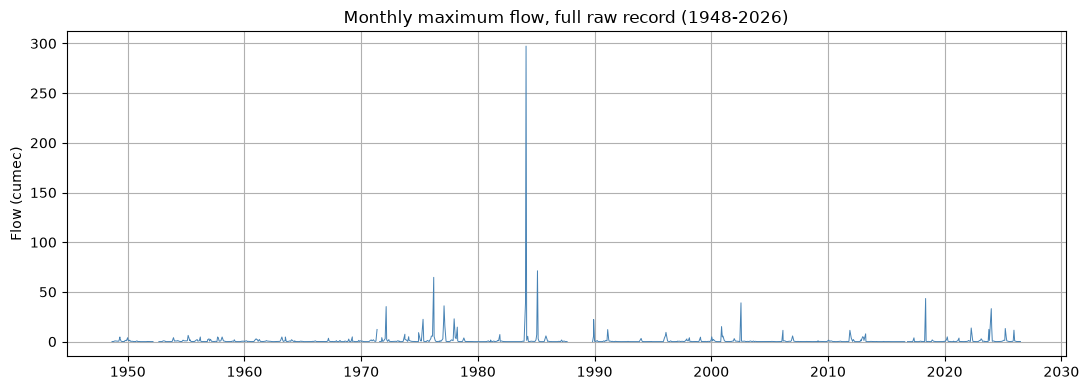

In [51]:
fig, ax = plt.subplots()
ax.plot(df["date"], df["flow"], linewidth=0.7, color="steelblue")
ax.set_ylabel("Flow (cumec)")
ax.set_title("Monthly maximum flow, full raw record (1948-2026)")
plt.tight_layout()
plt.show()

The record is heavily right-skewed — a handful of flood months (Feb 1984: 297 cumec; Feb 1985: 71 cumec) dominate an otherwise low, quiet series. This is real hydrology, not noise to be removed — these are exactly the events a future flood-risk system would care about most.

## 4. Data Cleaning 

droping every flagged row (M, Q, Z, <, >, $), keeping only unflagged or normal readings.

Consequences investigated before adopting this:

Removes all data from Aug 2023 onward (all Q-flagged / unaudited) — the record now ends 2023-07.


In [52]:
clean = df[df["flag"] == ""].copy().reset_index(drop=True)
print(f"Before: {len(df)} rows -> After dropping flagged rows: {len(clean)} rows "
      f"({len(df)-len(clean)} removed)")
print(f"Date range now: {clean['date'].min().date()} to {clean['date'].max().date()}")
print(f"Remaining missing values: level={clean['level'].isna().sum()}, flow={clean['flow'].isna().sum()}")


Before: 937 rows -> After dropping flagged rows: 828 rows (109 removed)
Date range now: 1948-09-19 to 2023-07-11
Remaining missing values: level=0, flow=0


## 5. Exploratory Data Analysis (on cleaned data)

Re-examining distribution, seasonality, and the level/flow relationship after cleaning, to confirm the
patterns found in Stage 3 survived the cleaning step.

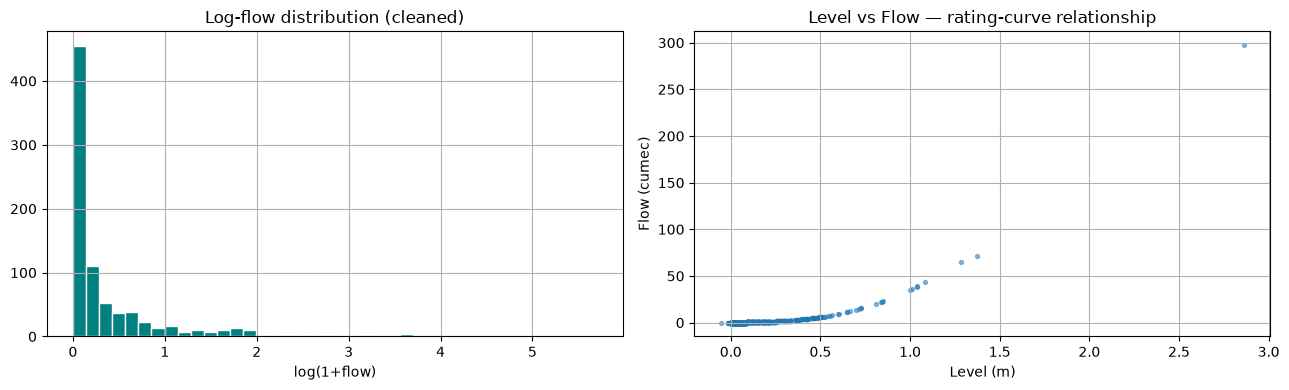

Pearson r, level vs log1p(flow): 0.963


In [53]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].hist(np.log1p(clean["flow"]), bins=40, color="teal", edgecolor="white")
axes[0].set_xlabel("log(1+flow)"); axes[0].set_title("Log-flow distribution (cleaned)")

axes[1].scatter(clean["level"], clean["flow"], s=8, alpha=0.5)
axes[1].set_xlabel("Level (m)"); axes[1].set_ylabel("Flow (cumec)")
axes[1].set_title("Level vs Flow — rating-curve relationship")
plt.tight_layout()
plt.show()

sub = clean.dropna(subset=["level","flow"])
print("Pearson r, level vs log1p(flow):", round(sub["level"].corr(np.log1p(sub["flow"])), 3))


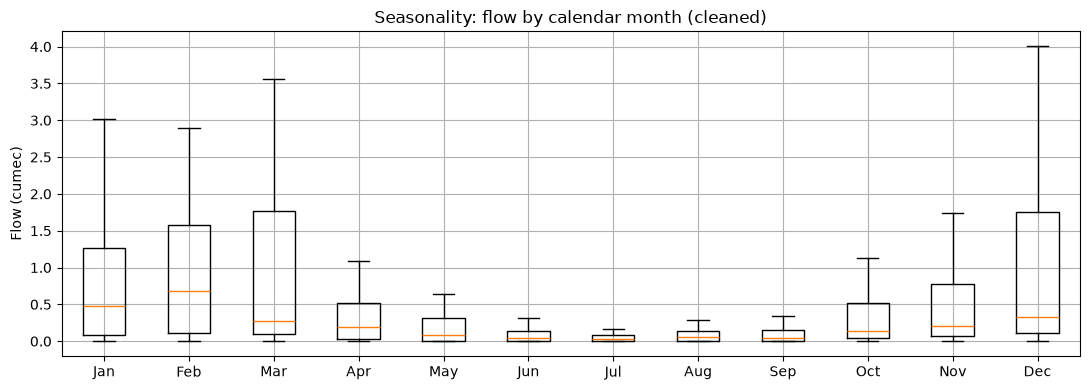

In [54]:
clean["month"] = clean["date"].dt.month
box = [clean.loc[clean["month"]==m, "flow"].values for m in range(1,13)]
fig, ax = plt.subplots()
ax.boxplot(box, tick_labels=["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"],
           showfliers=False)
ax.set_ylabel("Flow (cumec)"); ax.set_title("Seasonality: flow by calendar month (cleaned)")
plt.tight_layout()
plt.show()


Strong right skew persists (log1p transform used going forward), a clear wet-season (Dec-Mar) / dry-season (Jun-Sep) pattern consistent with South African summer rainfall, and a very strong level–log(flow) relationship (r≈0.96) reinforcing why same-month level cannot be used as a same-month predictor.

## 6. Feature Engineering

Reindex onto a continuous calendar-month grid first (`PeriodIndex`, monthly frequency), leaving
explicit `NaN` at the 71 gap months, and compute all lags/rolling stats on that grid. This guarantees
`lag_1` always means "the true previous calendar month," and rows adjacent to a gap correctly receive
`NaN` rather than a silently-wrong pulled-forward value.

In [55]:
clean["ym"] = clean["date"].dt.to_period("M")
grid = clean.set_index("ym").sort_index()
full_range = pd.period_range(grid.index.min(), grid.index.max(), freq="M")
grid = grid.reindex(full_range)
grid.index.name = "ym"
print(f"Continuous grid: {grid.shape[0]} calendar months "
      f"({grid['flow'].notna().sum()} observed, {grid['flow'].isna().sum()} gap)")

Continuous grid: 899 calendar months (828 observed, 71 gap)


In [56]:
grid["log_flow"] = np.log1p(grid["flow"])
grid["year"] = grid.index.year
grid["month"] = grid.index.month
grid["month_sin"] = np.sin(2*np.pi*grid["month"]/12)
grid["month_cos"] = np.cos(2*np.pi*grid["month"]/12)

for lag in [1, 2, 3, 6, 12]:
    grid[f"flow_lag_{lag}"] = grid["log_flow"].shift(lag)
    grid[f"level_lag_{lag}"] = grid["level"].shift(lag)

for win in [3, 6]:
    grid[f"flow_rolling_mean_{win}"] = grid["log_flow"].shift(1).rolling(win).mean()
    grid[f"flow_rolling_max_{win}"]  = grid["log_flow"].shift(1).rolling(win).max()
    grid[f"flow_rolling_std_{win}"]  = grid["log_flow"].shift(1).rolling(win).std()

feat_cols = ([c for c in grid.columns if c.startswith("flow_lag") or c.startswith("level_lag")
              or c.startswith("flow_rolling")] + ["month_sin", "month_cos", "year"])
print(f"{len(feat_cols)} features:", feat_cols)


19 features: ['flow_lag_1', 'level_lag_1', 'flow_lag_2', 'level_lag_2', 'flow_lag_3', 'level_lag_3', 'flow_lag_6', 'level_lag_6', 'flow_lag_12', 'level_lag_12', 'flow_rolling_mean_3', 'flow_rolling_max_3', 'flow_rolling_std_3', 'flow_rolling_mean_6', 'flow_rolling_max_6', 'flow_rolling_std_6', 'month_sin', 'month_cos', 'year']


Sanity check: a lag_1 immediately after a gap month must be NaN, not silently pulled from further back


In [57]:
gap_months = grid[grid["flow"].isna()].index
example = gap_months[0] + 1
print(f"Month after first gap ({gap_months[0]}): flow_lag_1 for {example} =",
      grid.loc[example, "flow_lag_1"], "(correctly NaN)")

Month after first gap (1949-04): flow_lag_1 for 1949-05 = nan (correctly NaN)


## 7. Target Definition

`Target = log1p(Flow) at month t`, using only features built from month `t-1` and earlier. This is a
strict 1-month-ahead forecast — no information from month `t` itself (including its own level) is used.

In [58]:
model_df = grid.dropna(subset=feat_cols + ["log_flow"]).copy()
print(f"Final modelling rows: {len(model_df)} of {len(grid)} calendar months")
print(f"Usable range: {model_df.index.min()} to {model_df.index.max()}")


Final modelling rows: 705 of 899 calendar months
Usable range: 1949-11 to 2023-07


## 8. Train / Validation / Test Split

Chronological split, no shuffling
- **Train:** 1949–2005
- **Validation:** 2006–2015
- **Test:** 2016–2023

This deliberately places the 2018 flood (43 cumec) in the test set, for an honest read on extreme-event
performance. Note: the actual test set ends up spanning 2017-11 to 2023-07 (n=59) rather than the full
2016-2023 window — this is a knock-on effect of the 2015-16 cleaning decision (Stage 4): those gap
months' absence propagates forward through the 12-month lag window, pushing the first fully-featured
test row to late 2017.

In [59]:
model_df["year_col"] = model_df.index.year
train = model_df[model_df["year_col"] <= 2005]
val   = model_df[(model_df["year_col"] >= 2006) & (model_df["year_col"] <= 2015)]
test  = model_df[model_df["year_col"] >= 2016]

for name, part in [("Train", train), ("Val", val), ("Test", test)]:
    print(f"{name:6s}: {part.index.min()} to {part.index.max()}  n={len(part)}")

X_train, y_train = train[feat_cols], train["log_flow"]
X_val, y_val = val[feat_cols], val["log_flow"]
X_test, y_test = test[feat_cols], test["log_flow"]


Train : 1949-11 to 2005-12  n=532
Val   : 2006-01 to 2015-06  n=114
Test  : 2017-11 to 2023-07  n=59


## 9. Baseline Model

A persistence forecast (`predicted flow = previous month's flow`) is the bar every ML model must clear.
Since flood-risk applications care disproportionately about extreme months, every evaluation below
also reports a **high-flow subset** (≥2.0 cumec, roughly the 90th percentile of the full record)
separately from the overall metrics — a model can look fine on average while failing exactly where it
matters most.

In [60]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

HIGH_FLOW_THRESH = 2.0  # cumec

def evaluate(y_true_log, y_pred_log, label, store=None):
    y_true = np.expm1(y_true_log)
    y_pred = np.clip(np.expm1(np.clip(y_pred_log, -10, 10)), 0, None)
    mae = mean_absolute_error(y_true, y_pred)
    rmse = mean_squared_error(y_true, y_pred) ** 0.5
    r2 = r2_score(y_true, y_pred)
    rmse_log = mean_squared_error(y_true_log, y_pred_log) ** 0.5
    hi = y_true >= HIGH_FLOW_THRESH
    hi_mae = mean_absolute_error(y_true[hi], y_pred[hi]) if hi.sum() > 0 else np.nan
    hi_rmse = mean_squared_error(y_true[hi], y_pred[hi]) ** 0.5 if hi.sum() > 0 else np.nan
    print(f"{label:28s} MAE={mae:7.3f}  RMSE={rmse:7.3f}  R2={r2:6.3f}  logRMSE={rmse_log:.3f} | "
          f"HighFlow(n={hi.sum():2d}) MAE={hi_mae:7.3f} RMSE={hi_rmse:7.3f}")
    row = dict(model=label, mae=mae, rmse=rmse, r2=r2, rmse_log=rmse_log, hi_mae=hi_mae, hi_rmse=hi_rmse)
    if store is not None:
        store.append(row)
    return row

val_results = []
evaluate(y_val.values, val["flow_lag_1"].values, "Persistence baseline (val)", store=val_results)


Persistence baseline (val)   MAE=  0.851  RMSE=  2.310  R2=-0.466  logRMSE=0.562 | HighFlow(n= 9) MAE=  5.485 RMSE=  6.488


{'model': 'Persistence baseline (val)',
 'mae': 0.8508508771929826,
 'rmse': 2.309981592164828,
 'r2': -0.4660630284329168,
 'rmse_log': 0.5623825881040276,
 'hi_mae': 5.48488888888889,
 'hi_rmse': 6.48751371653442}

## 10. Model Selection & Training

Candidates, deliberately starting simple: **Linear Regression**, **Random Forest**, **XGBoost**.
LSTM was considered and set aside — with only ~530 training rows, a deep model has no realistic
advantage over trees/linear models on this size of dataset, and we decided not to add it.

In [61]:
%pip install xgboost

Note: you may need to restart the kernel to use updated packages.


In [62]:
import sys
print(sys.version)

3.14.6 | packaged by Anaconda, Inc. | (main, Jul  9 2026, 14:29:05) [MSC v.1942 64 bit (AMD64)]


In [64]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

lin = LinearRegression().fit(X_train, y_train)
evaluate(y_val.values, lin.predict(X_val), "Linear Regression (val)", store=val_results)

rf_default = RandomForestRegressor(n_estimators=300, random_state=42, n_jobs=-1).fit(X_train, y_train)
evaluate(y_val.values, rf_default.predict(X_val), "Random Forest default (val)", store=val_results)

xgb_default = XGBRegressor(n_estimators=300, random_state=42, n_jobs=-1, verbosity=0).fit(X_train, y_train)
evaluate(y_val.values, xgb_default.predict(X_val), "XGBoost default (val)", store=val_results)

pd.DataFrame(val_results).sort_values("rmse_log")


Linear Regression (val)      MAE=  0.662  RMSE=  1.803  R2= 0.107  logRMSE=0.460 | HighFlow(n= 9) MAE=  4.897 RMSE=  6.172
Random Forest default (val)  MAE=  0.712  RMSE=  1.822  R2= 0.088  logRMSE=0.493 | HighFlow(n= 9) MAE=  4.688 RMSE=  6.117
XGBoost default (val)        MAE=  0.719  RMSE=  1.906  R2= 0.002  logRMSE=0.532 | HighFlow(n= 9) MAE=  5.196 RMSE=  6.411


,model,mae,rmse,r2,rmse_log,hi_mae,hi_rmse
1,Linear Regression (val),0.662257,1.802541,0.107300,0.460293,4.896784,6.172287
4,Linear Regression (val),0.662257,1.802541,0.107300,0.460293,4.896784,6.172287
5,Random Forest default (val),0.712218,1.822043,0.087878,0.492818,4.688064,6.117492
2,Random Forest default (val),0.712218,1.822043,0.087878,0.492818,4.688064,6.117492
6,XGBoost default (val),0.718506,1.905529,0.002376,0.531695,5.196379,6.410649
3,XGBoost default (val),0.718506,1.905529,0.002376,0.531695,5.196379,6.410649
0,Persistence baseline (val),0.850851,2.309982,-0.466063,0.562383,5.484889,6.487514


## 11. Model Evaluation


A closer look: actual vs predicted flow over the validation period.


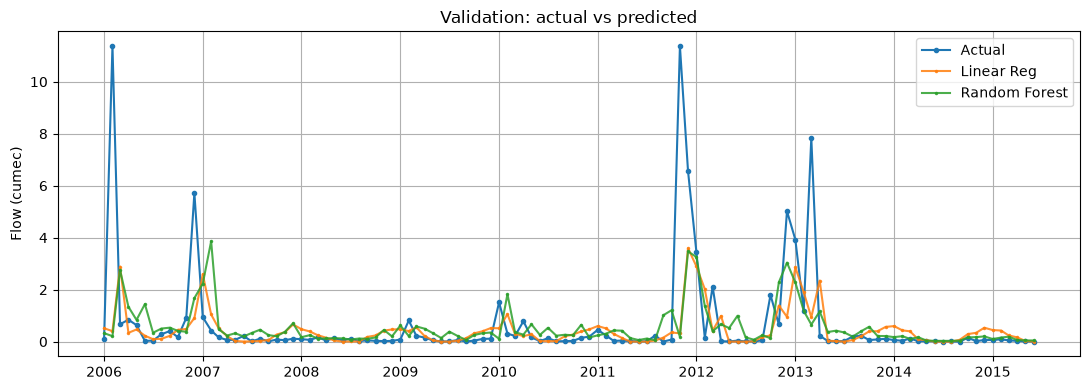

In [65]:
fig, ax = plt.subplots(figsize=(11, 4))
actual = np.expm1(y_val.values)
ax.plot(val.index.to_timestamp(), actual, label="Actual", marker="o", markersize=3)
ax.plot(val.index.to_timestamp(), np.clip(np.expm1(lin.predict(X_val)), 0, None),
        label="Linear Reg", marker=".", markersize=3, alpha=0.85)
ax.plot(val.index.to_timestamp(), np.clip(np.expm1(rf_default.predict(X_val)), 0, None),
        label="Random Forest", marker=".", markersize=3, alpha=0.85)
ax.set_ylabel("Flow (cumec)")
ax.set_title("Validation: actual vs predicted")
ax.legend()
plt.tight_layout()
plt.show()


Both models track the low-flow baseline reasonably well but **consistently underestimate every
flood peak** in the validation window (e.g. 2006: ~11.5 actual vs ~2.5 predicted; 2012: ~11.3 vs ~3.4).
This is a real limitation of the current feature set on rare extreme events, carried forward honestly
rather than hidden by aggregate metrics.


## 12. Hyperparameter Tuning


Tuning Ridge (regularised linear, since plain OLS won Stage 11), Random Forest, and XGBoost via
`RandomizedSearchCV` with a `TimeSeriesSplit` (5 folds) — a plain k-fold would leak future data into
earlier training folds, which is invalid for a time series. Tuning uses `train + val` combined; the
test set remains untouched until Stage 14.

In [67]:
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit
from sklearn.linear_model import Ridge

tscv = TimeSeriesSplit(n_splits=5)
X_tv = pd.concat([X_train, X_val]); y_tv = pd.concat([y_train, y_val])

ridge_search = RandomizedSearchCV(Ridge(), {"alpha":[0.01,0.1,0.3,1,3,10,30,100]},
    n_iter=8, cv=tscv, scoring="neg_root_mean_squared_error", random_state=42, n_jobs=-1)
ridge_search.fit(X_tv, y_tv)
print("Best Ridge alpha:", ridge_search.best_params_)

rf_param_dist = {"n_estimators":[200,300,500,700], "max_depth":[3,5,8,12,None],
                  "min_samples_leaf":[1,2,4,8], "max_features":["sqrt","log2",0.5,1.0]}
rf_search = RandomizedSearchCV(RandomForestRegressor(random_state=42,n_jobs=-1), rf_param_dist,
    n_iter=20, cv=tscv, scoring="neg_root_mean_squared_error", random_state=42, n_jobs=-1)
rf_search.fit(X_tv, y_tv)
print("Best RF params:", rf_search.best_params_)

xgb_param_dist = {"n_estimators":[200,300,500,700], "max_depth":[2,3,4,6,8],
                   "learning_rate":[0.01,0.03,0.05,0.1], "subsample":[0.6,0.8,1.0],
                   "colsample_bytree":[0.6,0.8,1.0]}
xgb_search = RandomizedSearchCV(XGBRegressor(random_state=42,n_jobs=-1,verbosity=0), xgb_param_dist,
    n_iter=20, cv=tscv, scoring="neg_root_mean_squared_error", random_state=42, n_jobs=-1)
xgb_search.fit(X_tv, y_tv)
print("Best XGB params:", xgb_search.best_params_)


Best Ridge alpha: {'alpha': 30}
Best RF params: {'n_estimators': 300, 'min_samples_leaf': 8, 'max_features': 'sqrt', 'max_depth': 5}
Best XGB params: {'subsample': 0.6, 'n_estimators': 300, 'max_depth': 6, 'learning_rate': 0.01, 'colsample_bytree': 0.6}


## 14. Final Model

Score every tuned candidate on the held-out **test set** for the first time.


In [68]:
test_results = []
evaluate(y_test.values, test["flow_lag_1"].values, "Persistence baseline", store=test_results)
evaluate(y_test.values, ridge_search.best_estimator_.predict(X_test), "Ridge (tuned)", store=test_results)
evaluate(y_test.values, rf_search.best_estimator_.predict(X_test), "Random Forest (tuned)", store=test_results)
evaluate(y_test.values, xgb_search.best_estimator_.predict(X_test), "XGBoost (tuned)", store=test_results)

pd.DataFrame(test_results).sort_values("rmse_log").reset_index(drop=True)


Persistence baseline         MAE=  2.398  RMSE=  8.348  R2=-1.048  logRMSE=0.872 | HighFlow(n= 7) MAE= 11.022 RMSE= 17.765
Ridge (tuned)                MAE=  1.402  RMSE=  5.967  R2=-0.046  logRMSE=0.677 | HighFlow(n= 7) MAE=  9.680 RMSE= 17.272
Random Forest (tuned)        MAE=  1.408  RMSE=  5.942  R2=-0.037  logRMSE=0.661 | HighFlow(n= 7) MAE=  9.393 RMSE= 17.199
XGBoost (tuned)              MAE=  1.409  RMSE=  5.958  R2=-0.043  logRMSE=0.674 | HighFlow(n= 7) MAE=  9.542 RMSE= 17.243


,model,mae,rmse,r2,rmse_log,hi_mae,hi_rmse
0,Random Forest (tuned),1.408051,5.942251,-0.037441,0.660632,9.393227,17.198851
1,XGBoost (tuned),1.409194,5.957949,-0.042930,0.673881,9.542345,17.243407
2,Ridge (tuned),1.402252,5.966765,-0.046018,0.677381,9.680395,17.271665
3,Persistence baseline,2.398068,8.347994,-1.047509,0.871772,11.022286,17.765041


**Final model: Random Forest (tuned).** Best log-RMSE and best high-flow MAE of the candidates,
though only marginally ahead of Ridge. All three roughly halve the persistence baseline's error.

**limitation:** R² is still slightly negative on the test set for every model. With only 7
high-flow months in a 59-row test set, a couple of large flood misses dominate the variance — even the
best model doesn't yet beat "predict the mean" by this particular metric. This reflects genuine
extreme-event sparsity, not something hyperparameter tuning can fix; a larger flood-event sample (or a
dedicated extreme-value modelling approach) would be needed to move this further.


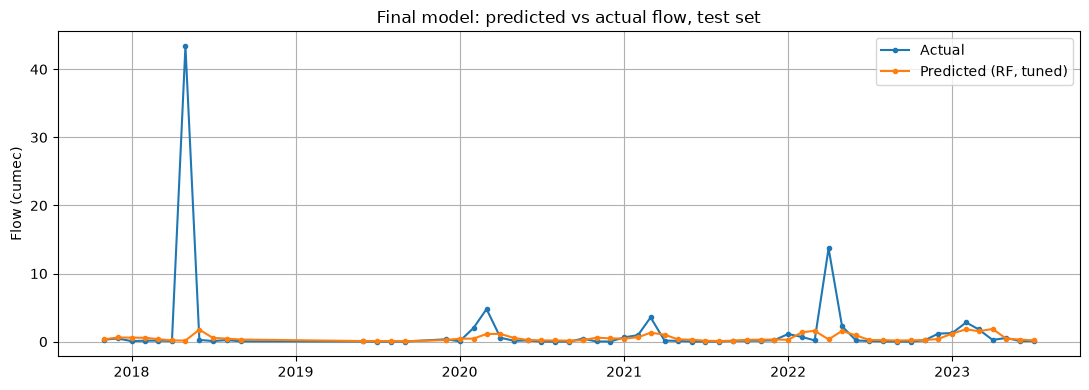

In [69]:
fig, ax = plt.subplots(figsize=(11, 4))
final_model = rf_search.best_estimator_
actual_test = np.expm1(y_test.values)
pred_test = np.clip(np.expm1(final_model.predict(X_test)), 0, None)
ax.plot(test.index.to_timestamp(), actual_test, label="Actual", marker="o", markersize=3)
ax.plot(test.index.to_timestamp(), pred_test, label="Predicted (RF, tuned)", marker="o", markersize=3)
ax.set_ylabel("Flow (cumec)")
ax.set_title("Final model: predicted vs actual flow, test set")
ax.legend()
plt.tight_layout()
plt.show()


## 15. Interpretation

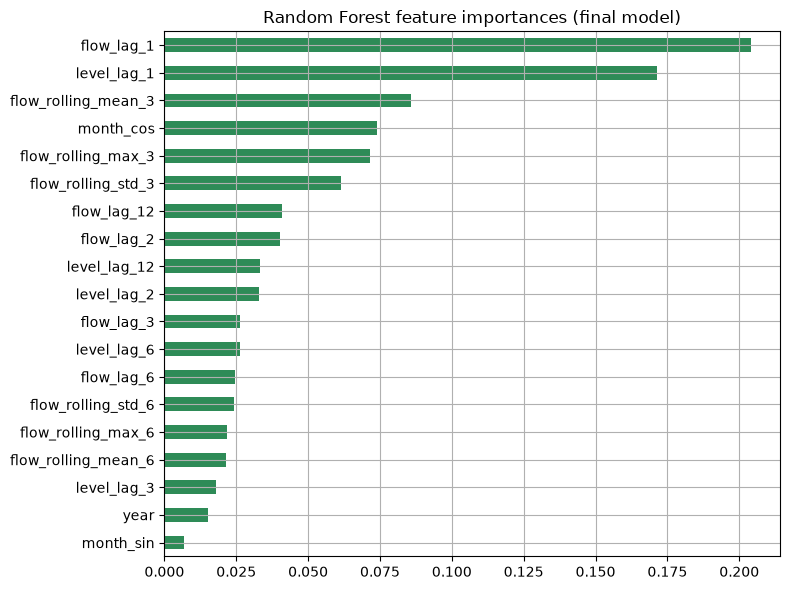

flow_lag_1             0.203974
level_lag_1            0.171260
flow_rolling_mean_3    0.085676
month_cos              0.074050
flow_rolling_max_3     0.071669
flow_rolling_std_3     0.061582
flow_lag_12            0.040833
flow_lag_2             0.040223
level_lag_12           0.033159
level_lag_2            0.032789
flow_lag_3             0.026217
level_lag_6            0.026179
flow_lag_6             0.024680
flow_rolling_std_6     0.024351
flow_rolling_max_6     0.021933
flow_rolling_mean_6    0.021327
level_lag_3            0.018100
year                   0.015215
month_sin              0.006783
dtype: float64

In [70]:
importances = pd.Series(final_model.feature_importances_, index=feat_cols).sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(8,6))
importances.plot(kind="barh", ax=ax, color="seagreen")
ax.invert_yaxis()
ax.set_title("Random Forest feature importances (final model)")
plt.tight_layout()
plt.show()
importances


`flow_lag_1` and `level_lag_1` (last month's flow and level) dominate, together ~37% of importance
— recent conditions are the strongest predictor of what comes next, which matches physical intuition.
3-month rolling stats matter more than 6-month ones, and `month_cos` (seasonality) outranks most
individual lags. `year` (long-term trend) contributes very little — no strong drift beyond the seasonal
wet/dry cycle across the 78-year record.


In [71]:
import joblib
full_X = pd.concat([X_train, X_val, X_test])
full_y = pd.concat([y_train, y_val, y_test])
deployed_model = RandomForestRegressor(**rf_search.best_params_, random_state=42, n_jobs=-1)
deployed_model.fit(full_X, full_y)
joblib.dump(deployed_model, "river_flow_rf_model.joblib")
joblib.dump(feat_cols, "river_flow_feature_cols.joblib")
print("Refit on all available data (train+val+test) and saved for deployment.")


Refit on all available data (train+val+test) and saved for deployment.
